In [2]:
import os
import sys
import zarr
import numpy as np
import xarray as xr
from glob import glob

In [3]:
#import wrf

In [4]:
sys.path.insert(0, os.path.realpath('../libs/'))
import plevel_utils as pu

In [5]:
import cmaps
# graph tools
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import matplotlib.colorbar as cbar
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy.crs as ccrs
import cartopy.mpl.geoaxes
import cartopy.feature as cfeature

%matplotlib inline

In [6]:
# import matplotlib.pyplot as plt
# %matplotlib inline

In [7]:
import time

## Variable info

In [7]:
GRAVITY = pu.GRAVITY

def vertical_integral(var, p, g=GRAVITY):
    """
    Compute pressure-level vertical integral using the trapezoidal rule:
    ∫ var * dp / g
    
    Parameters:
        var (xr.DataArray): Variable to integrate (e.g., q, q*u, q*v)
        p   (xr.DataArray): Pressure with same dimensions as var
        g   (float): Gravitational acceleration (default 9.80665 m/s²)
        
    Returns:
        xr.DataArray: Vertically integrated result with bottom_top removed
    """
    dp = -p.diff(dim='bottom_top')
    var_mid = 0.5 * (var.isel(bottom_top=slice(0, -1)) + var.isel(bottom_top=slice(1, None)))
    return ((var_mid * dp) / g).sum(dim='bottom_top')


def wrf_destag(darray, stagger_dim):
    if stagger_dim not in darray.dims:
        raise ValueError(f"Dimension '{stagger_dim}' not found in input DataArray.")
    
    return 0.5 * (darray.isel({stagger_dim: slice(0, -1)}) +
                  darray.isel({stagger_dim: slice(1, None)}))

var_2d = [
    'ACDEWC', 'ACDRIPR', 'ACDRIPS', 'ACECAN', 'ACEDIR', 'ACETLSM',
    'ACETRAN', 'ACEVAC', 'ACEVB', 'ACEVC', 'ACEVG', 'ACFROC',
    'ACFRZC', 'ACGHB', 'ACGHFLSM', 'ACGHV', 'ACINTR', 'ACINTS',
    'ACIRB', 'ACIRC', 'ACIRG', 'ACLHFLSM', 'ACLWDNB', 'ACLWDNBC',
    'ACLWDNLSM', 'ACLWDNT', 'ACLWDNTC', 'ACLWUPB', 'ACLWUPBC', 'ACLWUPLSM',
    'ACLWUPT', 'ACLWUPTC', 'ACMELTC', 'ACPAHB', 'ACPAHG', 'ACPAHLSM',
    'ACPAHV', 'ACPONDING', 'ACQLAT', 'ACQRF', 'ACRAINLSM', 'ACRAINSNOW',
    'ACRUNSB', 'ACRUNSF', 'ACSAGB', 'ACSAGV', 'ACSAV', 'ACSHB',
    'ACSHC', 'ACSHFLSM', 'ACSHG', 'ACSNBOT', 'ACSNFRO', 'ACSNOM',
    'ACSNOWLSM', 'ACSNSUB', 'ACSUBC', 'ACSWDNB', 'ACSWDNBC', 'ACSWDNLSM',
    'ACSWDNT', 'ACSWDNTC', 'ACSWUPB', 'ACSWUPBC', 'ACSWUPLSM', 'ACSWUPT',
    'ACSWUPTC', 'ACTHROR', 'ACTHROS', 'ACTR', 'ALBEDO', 'CANICE',
    'CANWAT', 'COSZEN', 'EMISS', 'FORCPLSM', 'FORCQLSM', 'FORCTLSM',
    'FORCWLSM', 'FORCZLSM', 'GLW', 'GRAUPEL_ACC_NC', 'HFX', 'I_ACLWDNB',
    'I_ACLWDNBC', 'I_ACLWDNT', 'I_ACLWDNTC', 'I_ACLWUPB', 'I_ACLWUPBC', 'I_ACLWUPT',
    'I_ACLWUPTC', 'I_ACSWDNB', 'I_ACSWDNBC', 'I_ACSWDNT', 'I_ACSWDNTC', 'I_ACSWUPB',
    'I_ACSWUPBC', 'I_ACSWUPT', 'I_ACSWUPTC', 'LAI', 'LH', 'LWDNB',
    'LWDNBC', 'LWDNT', 'LWDNTC', 'LWUPB', 'LWUPBC', 'LWUPT',
    'LWUPTC', 'MLCAPE', 'MLCINH', 'MLLCL', 'MU', 'MUCAPE',
    'MUCINH', 'OLR', 'P', 'PBLH', 'PREC_ACC_NC', 'PSFC',
    'PWAT', 'Q2', 'QFX', 'QRFS', 'QSLAT', 'QSPRINGS',
    'QVAPOR', 'RAINNCV', 'RECH', 'REFL_10CM', 'REFL_1KM_AGL', 'REFL_COM',
    'SBCAPE', 'SBCINH', 'SBLCL', 'SEAICE', 'SH2O', 'SMCWTD',
    'SMOIS', 'SNICE', 'SNLIQ', 'SNOW', 'SNOWC', 'SNOWENERGY',
    'SNOWH', 'SNOW_ACC_NC', 'SOILENERGY', 'SR', 'SRH01', 'SRH03',
    'SST', 'SSTSK', 'SWDNB', 'SWDNBC', 'SWDNT', 'SWDNTC',
    'SWDOWN', 'SWNORM', 'SWUPB', 'SWUPBC', 'SWUPT', 'SWUPTC',
    'T2', 'TD2', 'TG', 'TH2', 'TK', 'TRAD',
    'TSK', 'TSLB', 'TSNO', 'TV', 'Times', 'U',
    'U10', 'USHR1', 'USHR6', 'UST', 'U_BUNK', 'V',
    'V10', 'VSHR1', 'VSHR6', 'V_BUNK', 'W', 'Z',
    'ZSNSO', 'ZWT', 'totalIce', 'totalLiq', 'totalVap',
    'index_snow_layers_stag', 'index_snso_layers_stag', 'index_soil_layers_stag'
]

# QCLOUD, QGRAUP, QICE, QRAIN, QSNOW

var_3d = [
    'CLDFRA', 'O3RAD', 'P', 'P_HYD', 'QCLOUD',
    'QGRAUP', 'QICE', 'QNICE', 'QNRAIN', 'QRAIN',
    'QSNOW', 'QVAPOR', 'REFL_10CM', 'TK', 'Times',
    'U', 'V', 'W', 'Z', 'ilev', 'lev'
]

var_2d_pick = ['T2', 'TD2', 'U10', 'V10', 'PSFC', 'ACETLSM', 
               'PREC_ACC_NC', 'PWAT', 'REFL_COM', 'MLCAPE', 'OLR', 'Z', 'PSFC']

var_3d_pick= ['TK', 'U', 'V', 'P', 'Z', 'CLDFRA', 'QVAPOR', 
              'QCLOUD', 'QGRAUP', 'QICE', 'QRAIN', 'QSNOW']

#, 'QCLOUD', 'QGRAUP', 'QICE', 'QRAIN', 'QSNOW']

var_2d_drop = list(set(var_2d) - set(var_2d_pick))
var_3d_drop = list(set(var_3d) - set(var_3d_pick))

rename_final = {
    'T2': 'WRF_T2',
    'TD2': 'WRF_TD2',
    'U10': 'WRF_U10',
    'V10': 'WRF_V10',
    'ACETLSM': 'WRF_evapor', 
    'PREC_ACC_NC': 'WRF_precip', 
    'PSFC': 'WRF_SP',
    'PWAT': 'WRF_PWAT',
    'TK_3d': 'WRF_T',
    'P_3d': 'WRF_P',
    'U': 'WRF_U',
    'V': 'WRF_V',
    'QVAPOR': 'WRF_Q',
    'REFL_COM': 'WRF_radar_composite',
    'MLCAPE': 'WRF_MLCAPE',
    'OLR': 'WRF_OLR'
}

varname_4d = [
    'WRF_T',
    'WRF_P',
    'WRF_U',
    'WRF_V',
    'WRF_Q',
    'WRF_Q_tot'
    'WRF_Q_LC'
]

In [8]:
rename_3d = {'TK': 'TK_3d', 'P': 'P_3d', 'Z': 'Z_3d'}
rename_2d = {'Z': 'Z_2d'}

In [9]:
#level_pick = [0, 6, 9, 12, 15, 18, 21, 24, 30, 36, 42, 48]
level_pick = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 21, 24, 30, 36, 42, 49]

varname_time = 'Time'
varname_lat = 'south_north'
varname_lon = 'west_east'

dim_3D = (varname_time, varname_lat, varname_lon)

## Domain and static info

In [10]:
# static_name = '/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_GP/static/C404_GP_static.zarr'
# ds_static = xr.open_zarr(static_name)

# GP_surf = ds_static['HGT_M'].values * GRAVITY 

## Native model level main loop

In [11]:
domain_inds = np.arange(336).astype(np.float32)
level_inds = np.arange(len(level_pick)).astype(np.float32)

pressure = np.array(
    [1000, 960, 940, 920, 880, 850, 800, 750, 680, 610, 500, 420, 280, 180, 100, 50]
).astype(np.float32)

In [ ]:
fn_2d_full = sorted(glob('/glade/campaign/collections/rda/data/d559000/wy*/*/wrf2d*'))
ind_start = 100
ind_end = 120

fn_2d_subset = fn_2d_full[ind_start:ind_end]
L = len(fn_2d_subset)

for i in range(L):
    start_time = time.time()    
    fn_2d = fn_2d_subset[i]
    fn_3d = fn_2d[:62] + '3d' + fn_2d[64:]
    
    ds_2d = xr.open_dataset(fn_2d, drop_variables=var_2d_drop)
    ds_2d = ds_2d.drop_vars(['XLAT_U', 'XLONG_U', 'XLAT_V', 'XLONG_V'])
    
    # ------------------------------------------------------------ #
    # 3d destag
    ds_3d = xr.open_dataset(fn_3d, drop_variables=var_3d_drop)
    # convert to geopotential
    # ds_3d['Z'] = ds_3d['Z'] * GRAVITY 
    # Z_destag_3d = wrf_destag(ds_3d['Z'], 'bottom_top_stag')
    # Z_destag_3d = Z_destag_3d.rename({'bottom_top_stag': 'bottom_top'})
    # ds_3d = ds_3d.drop_vars(['Z',])
    # ds_3d['Z'] = Z_destag_3d
    
    U_destag_3d = wrf_destag(ds_3d['U'], 'west_east_stag')
    U_destag_3d = U_destag_3d.rename({'west_east_stag': 'west_east'})
    
    V_destag_3d = wrf_destag(ds_3d['V'], 'south_north_stag')
    V_destag_3d = V_destag_3d.rename({'south_north_stag': 'south_north'})
    
    ds_3d = ds_3d.drop_vars(['U',])
    ds_3d['U'] = U_destag_3d
    
    ds_3d = ds_3d.drop_vars(['V',])
    ds_3d['V'] = V_destag_3d
    
    ds_3d = ds_3d.drop_vars(['XLAT_U', 'XLONG_U', 'XLAT_V', 'XLONG_V'])
    
    # -------------------------------------------------------- #
    # merge together
    ds_2d = ds_2d.rename(rename_2d)
    ds_3d = ds_3d.rename(rename_3d)
    
    ds_mlevel = xr.merge([ds_2d, ds_3d])    
    ds_mlevel = ds_mlevel.isel(west_east=slice(90, 425+1, 1), south_north=slice(450, 785+1, 1))
    ds_mlevel = ds_mlevel.map(lambda x: x.astype(np.float32) if x.dtype == np.float64 else x)

    # -------------------------------------------------------- #
    # Q_tot
    ds_mlevel['WRF_Q_tot'] = ds_mlevel['QVAPOR'] + \
                             ds_mlevel['QCLOUD'] + \
                             ds_mlevel['QGRAUP'] + \
                             ds_mlevel['QICE'] + \
                             ds_mlevel['QRAIN'] + \
                             ds_mlevel['QSNOW']
    
    ds_mlevel['WRF_Q_LC'] = ds_mlevel['QCLOUD'] + \
                            ds_mlevel['QGRAUP'] + \
                            ds_mlevel['QICE'] + \
                            ds_mlevel['QRAIN'] + \
                            ds_mlevel['QSNOW'] 
    
    # integrate_Q_LC
    ds_mlevel['WRF_PWAT_LC'] = vertical_integral(ds_mlevel['WRF_Q_LC'], ds_mlevel['P_3d'])
    
    # IVT components
    ds_mlevel['WRF_IVT_U'] = vertical_integral(ds_mlevel['WRF_Q_tot'] * ds_mlevel['U'], ds_mlevel['P_3d'])
    ds_mlevel['WRF_IVT_V'] = vertical_integral(ds_mlevel['WRF_Q_tot'] * ds_mlevel['V'], ds_mlevel['P_3d'])
    
    # -------------------------------------------------------- #
    # MSLP conversion
    ds_raw = ds_mlevel
    
    coords_surface = {
            varname_time: ds_raw[varname_time],
            varname_lat: ds_raw[varname_lat],
            varname_lon: ds_raw[varname_lon],
    }
    
    pressure_3D = ds_raw['P_3d'].values
    GP_3D = ds_raw['Z_3d'].values
    T_3D = ds_raw['TK_3d'].values
    Z_model_bot = ds_raw['Z_2d'].values
    PSFC = ds_raw['PSFC'].values

    MSLP = xr.Dataset(
        data_vars={
            'WRF_MSLP': xr.DataArray(
                coords=coords_surface,
                dims=dim_3D,
                name='WRF_MSLP',
            )
        },
        coords=coords_surface,
    )

    for t, time_val in enumerate(ds_raw[varname_time]):
        MSLP['WRF_MSLP'][t] = (
            pu.MSLP_convert(
                PSFC[t],
                T_3D[t],
                pressure_3D[t],
                Z_model_bot[t],
                GP_3D[t],
                temp_height=150.0,
            )
        )
        
    # -------------------------------------------------------- #
    # Total Cloud Cover (TCC)
    ds_mlevel['WRF_TCC'] = 1.0 - (1.0 - ds_mlevel['CLDFRA']).prod(dim='bottom_top', skipna=False)
    
    ds_mlevel = xr.merge([ds_mlevel, MSLP])

    ds_mlevel = ds_mlevel.map(lambda x: x.astype(np.float32) if x.dtype == np.float64 else x)
    ds_mlevel = ds_mlevel.drop_vars(['QCLOUD', 'QGRAUP', 'QICE', 'QRAIN', 'QSNOW', 
                                     'Z_2d', 'CLDFRA', 'Z_3d'])
    
    ds_mlevel = ds_mlevel.isel(bottom_top=level_pick)
    ds_mlevel = ds_mlevel.rename(rename_final)
    
    ds_mlevel = ds_mlevel.rename({'Time': 'time'})    
    ds_mlevel = ds_mlevel.reset_coords(drop=True)
    ds_mlevel = ds_mlevel.assign_coords(
        south_north=domain_inds, 
        west_east=domain_inds, 
        bottom_top=level_inds,
        pressure_approx=pressure
    )
    
    if i == 0:
        varnames = list(ds_mlevel.keys())
        # zarr encodings
        dict_encoding = {}
        
        chunk_size_3d = dict(chunks=(12, 336, 336))
        chunk_size_4d = dict(chunks=(12, 16, 336, 336))
        
        compress = zarr.Blosc(cname='zstd', clevel=1, shuffle=zarr.Blosc.SHUFFLE, blocksize=0)
        
        for i_var, var in enumerate(varnames):
            if var in varname_4d:
                dict_encoding[var] = {'compressor': compress, **chunk_size_4d}
            else:
                dict_encoding[var] = {'compressor': compress, **chunk_size_3d}
    
    save_name = '/glade/campaign/ral/hap/ksha/DWC_data/CONUS_domain_PNW/raw_404/' + 'C404_PNW_' + fn_2d[-22:-9] + 'H.zarr'
    # print(save_name)
    # ds_mlevel.to_zarr(save_name, mode='w', consolidated=True, compute=True, encoding=dict_encoding)
    print("--- %s seconds ---" % (time.time() - start_time))

/glade/campaign/ral/hap/ksha/DWC_data/CONUS_domain_PNW/raw_404/C404_PNW_1979-10-05_04H.zarr
--- 48.7736713886261 seconds ---
/glade/campaign/ral/hap/ksha/DWC_data/CONUS_domain_PNW/raw_404/C404_PNW_1979-10-05_05H.zarr
--- 36.54788875579834 seconds ---
/glade/campaign/ral/hap/ksha/DWC_data/CONUS_domain_PNW/raw_404/C404_PNW_1979-10-05_06H.zarr
--- 39.46897053718567 seconds ---
/glade/campaign/ral/hap/ksha/DWC_data/CONUS_domain_PNW/raw_404/C404_PNW_1979-10-05_07H.zarr
--- 36.02984356880188 seconds ---
/glade/campaign/ral/hap/ksha/DWC_data/CONUS_domain_PNW/raw_404/C404_PNW_1979-10-05_08H.zarr
--- 36.284194469451904 seconds ---
/glade/campaign/ral/hap/ksha/DWC_data/CONUS_domain_PNW/raw_404/C404_PNW_1979-10-05_09H.zarr
--- 36.2635440826416 seconds ---


In [1]:
20*60*60/45

1600.0

In [19]:
ds = xr.open_zarr('/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_GP/all_in_one/C404_GP_2022.zarr')

In [20]:
print(ds.isnull().any().to_array().any().compute().item())

False


In [21]:
ds = xr.open_zarr('/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_GP/all_in_one/C404_GP_1988.zarr')

In [22]:
print(ds.isnull().any().to_array().any().compute().item())

False


In [23]:
ds = xr.open_zarr('/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_GP/all_in_one/C404_GP_1987.zarr')
print(ds.isnull().any().to_array().any().compute().item())

False


In [24]:
ds

<xarray.Dataset>
Dimensions:              (time: 8760, south_north: 336, west_east: 336,
                          bottom_top: 16, pressure_approx: 16)
Coordinates:
  * bottom_top           (bottom_top) float32 0.0 1.0 2.0 3.0 ... 13.0 14.0 15.0
  * pressure_approx      (pressure_approx) float32 1e+03 960.0 ... 100.0 50.0
  * south_north          (south_north) float32 0.0 1.0 2.0 ... 333.0 334.0 335.0
  * time                 (time) datetime64[ns] 1987-01-01 ... 1987-12-31T23:0...
  * west_east            (west_east) float32 0.0 1.0 2.0 ... 333.0 334.0 335.0
Data variables: (12/20)
    WRF_IVT_U            (time, south_north, west_east) float32 dask.array<chunksize=(8, 336, 336), meta=np.ndarray>
    WRF_IVT_V            (time, south_north, west_east) float32 dask.array<chunksize=(8, 336, 336), meta=np.ndarray>
    WRF_MSLP             (time, south_north, west_east) float32 dask.array<chunksize=(8, 336, 336), meta=np.ndarray>
    WRF_OLR              (time, south_north, west_east) float32 dask.array<chunksize=(8, 336, 336), meta=np.ndarray>
    WRF_P                (time, bottom_top, south_north, west_east) float32 dask.array<chunksize=(8, 16, 336, 336), meta=np.ndarray>
    WRF_PWAT             (time, south_north, west_east) float32 dask.array<chunksize=(8, 336, 336), meta=np.ndarray>
    ...                   ...
    WRF_U                (time, bottom_top, south_north, west_east) float32 dask.array<chunksize=(8, 16, 336, 336), meta=np.ndarray>
    WRF_U10              (time, south_north, west_east) float32 dask.array<chunksize=(8, 336, 336), meta=np.ndarray>
    WRF_V                (time, bottom_top, south_north, west_east) float32 dask.array<chunksize=(8, 16, 336, 336), meta=np.ndarray>
    WRF_V10              (time, south_north, west_east) float32 dask.array<chunksize=(8, 336, 336), meta=np.ndarray>
    WRF_precip           (time, south_north, west_east) float32 dask.array<chunksize=(8, 336, 336), meta=np.ndarray>
    WRF_radar_composite  (time, south_north, west_east) float32 dask.array<chunksize=(8, 336, 336), meta=np.ndarray>

In [26]:
WRF_PWAT_LC_np = ds_mlevel['WRF_PWAT_LC'].values

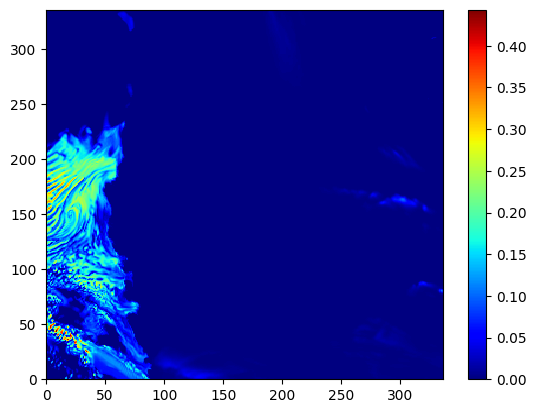

In [27]:
plt.pcolormesh(WRF_PWAT_LC_np[0, ...], cmap=plt.cm.jet)
plt.colorbar()

In [20]:
MSLP_np = ds_mlevel['WRF_MSLP'].values

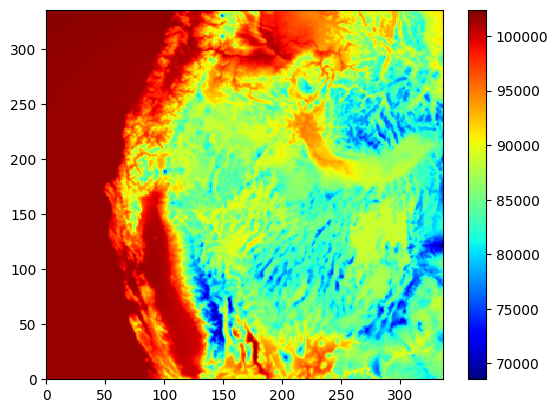

In [22]:
plt.pcolormesh(MSLP_np[0, ...], cmap=plt.cm.jet)
plt.colorbar()